In [1]:
import torch
import torch.nn as nn
import pandas as pd
import random
import string
import matplotlib.pyplot as plt

In [2]:
# Loading the SMS spam dataset
df = pd.read_csv(
    "SMSSpamCollection.txt",
    sep="\t",
    header=None,
    names=["label", "message"],
    encoding="latin-1"
)

# Clean spaces/newlines
df["label"] = df["label"].astype(str).str.strip()

# Convert labels
df["label"] = df["label"].replace({
    "ham": 0,
    "spam": 1
})

# Removing bad rows
df = df.dropna(subset=["label", "message"])

# Convert types
df["label"] = df["label"].astype(int)
df["message"] = df["message"].astype(str)

# Resetting the index
df = df.reset_index(drop=True)

print(df.head())
print(df.shape)
print(df["label"].unique())

   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...
(5572, 2)
[0 1]


In [3]:
# Reducing Size
df = df.sample(n=min(2000, len(df)), random_state=42)

In [4]:
# Creating list of allowed characters
ALL_LETTERS = string.ascii_letters + " .,;'!?0123456789"
N_LETTERS = len(ALL_LETTERS)

def letter_to_index(letter):
    return ALL_LETTERS.find(letter)

def line_to_tensor(line):
    line = str(line)
    filtered_line = ""

    for letter in line:
        if letter in ALL_LETTERS:
            filtered_line += letter

    if len(filtered_line) == 0:
        filtered_line = " "

    tensor = torch.zeros(len(filtered_line), 1, N_LETTERS)

    # One-hot encoding
    for i, letter in enumerate(filtered_line):

        index = letter_to_index(letter)

        if index >= 0:
            tensor[i][0][index] = 1

    return tensor

In [5]:
# Building Recurrent Neural Network
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size

        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        self.i2o = nn.Linear(input_size + hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    # Forward pass
    def forward(self, input_tensor, hidden_tensor):
        combined = torch.cat((input_tensor, hidden_tensor), 1)
        hidden = self.i2h(combined)
        output = self.i2o(combined)
        output = self.softmax(output)
        return output, hidden
    
    # Initialize hidden state
    def init_hidden(self):
        return torch.zeros(1, self.hidden_size)

In [6]:
# Setup Model Parameters

# Hidden layer size
n_hidden = 128
n_categories = 2

# Creating RNN model
rnn = RNN(N_LETTERS, n_hidden, n_categories)

criterion = nn.NLLLoss()
optimizer = torch.optim.SGD(rnn.parameters(), lr=0.001)

In [7]:
# Generating Random Training Example

def random_training_example():
    idx = random.randint(0, len(df)-1)
    row = df.iloc[idx]

    message = str(row["message"])
    label = row["label"]

    if label == "ham":
        label = 0
    elif label == "spam":
        label = 1

    label = int(label)

    category_tensor = torch.tensor([label], dtype=torch.long)
    line_tensor = line_to_tensor(message)
    return message, label, category_tensor, line_tensor

In [8]:
# Training Function

def train(line_tensor, category_tensor):
    hidden = rnn.init_hidden()

    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)

    loss = criterion(output, category_tensor)

    optimizer.zero_grad()
    loss.backward()

    # Prevent exploding gradients
    torch.nn.utils.clip_grad_norm_(rnn.parameters(), 5)

    optimizer.step()

    return output, loss.item()

In [9]:
# Training the RNN model

n_iters = 5000
all_losses = []
current_loss = 0

for i in range(n_iters):
    message, label, category_tensor, line_tensor = random_training_example()

    output, loss = train(line_tensor, category_tensor)
    current_loss += loss

    # Print progress every 500 steps
    if (i+1) % 500 == 0:
        all_losses.append(current_loss / 500)
        current_loss = 0
        print(f"Step {i+1}, Loss: {loss:.4f}")

Step 500, Loss: 0.4353
Step 1000, Loss: 0.2860
Step 1500, Loss: 0.2437
Step 2000, Loss: 0.1493
Step 2500, Loss: 1.7969
Step 3000, Loss: 0.0965
Step 3500, Loss: 0.0961
Step 4000, Loss: 0.1030
Step 4500, Loss: 0.1283
Step 5000, Loss: 0.1344


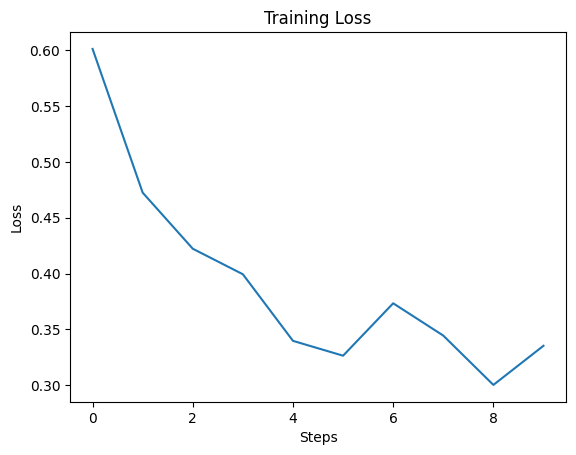

In [10]:
# Plot Training Loss

plt.plot(all_losses)
plt.title("Training Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.show()

In [11]:
# Predicting Spam or Legitimate
def predict(input_line):

    with torch.no_grad():

        line_tensor = line_to_tensor(input_line)

        hidden = rnn.init_hidden()

        for i in range(line_tensor.size()[0]):
            output, hidden = rnn(
                line_tensor[i],
                hidden
            )

        # Get Prediction
        prediction = torch.argmax(output).item()

        # return Label
        if prediction == 1:
            return "Spam"
        
        else:
            return "Legitimate"

In [12]:
# Test Predictions
print(
    predict(
        "Congratulations! You won a free iPhone"
    )
)

print(
    predict(
        "Hey are we still meeting today?"
    )
)

print(
    predict(
        "URGENT! Claim your cash reward now"
    )
)

Legitimate
Legitimate
Legitimate
